In [1]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import cv2

In [2]:
real_path = r"C:\Users\PRO\Desktop\Techolas project\DeepFake\Audio\Audio Dataset\RealAudios"
fake_path = r"C:\Users\PRO\Desktop\Techolas project\DeepFake\Audio\Audio Dataset\FakeAudios"

# Get first speaker folder
speaker_folder = os.listdir(real_path)[0]
speaker_path = os.path.join(real_path, speaker_folder)

# Get first audio file inside that speaker folder
audio_file = os.listdir(speaker_path)[0]
file_path = os.path.join(speaker_path, audio_file)

# Load audio
audio, sr = librosa.load(file_path, sr=22050)

print("Speaker folder:", speaker_folder)
print("Audio file:", audio_file)
print("Audio shape:", audio.shape)
print("Sample rate:", sr)
print("Duration (seconds):", len(audio)/sr)

Speaker folder: speaker10_recordings
Audio file: speaker10_input1.wav
Audio shape: (166698,)
Sample rate: 22050
Duration (seconds): 7.56


In [3]:
durations = []

for speaker in os.listdir(real_path):
    speaker_path = os.path.join(real_path, speaker)
    for file in os.listdir(speaker_path):
        audio, sr = librosa.load(os.path.join(speaker_path, file), sr=22050)
        durations.append(len(audio)/sr)

print("Average duration:", sum(durations)/len(durations))

Average duration: 7.320293910667716


In [4]:
audio, sr = librosa.load(file_path, sr=22050)

## Convert to Mel Spectrogram (128x128)

In [5]:
def audio_to_melspectrogram(audio, sr):
    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )
    
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    return mel_spec_db

### Test Spectrogram

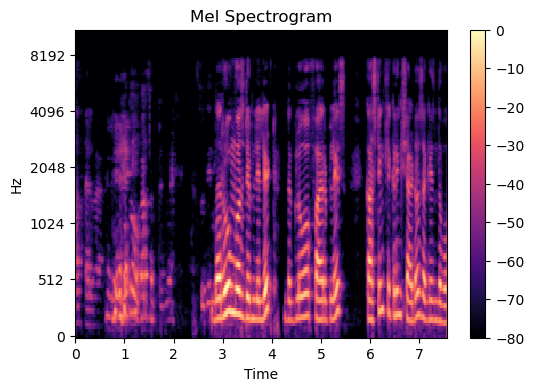

Shape: (128, 326)


In [6]:
mel = audio_to_melspectrogram(audio, sr)

plt.figure(figsize=(6,4))
librosa.display.specshow(mel, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

print("Shape:", mel.shape)

### Resize Spectrogram to 128x128

In [7]:
import tensorflow as tf

def resize_spectrogram(mel_spec, target_size=(128, 128)):
    mel_spec = np.expand_dims(mel_spec, axis=-1)  # add channel dimension
    mel_spec_resized = tf.image.resize(mel_spec, target_size)
    return mel_spec_resized.numpy()

In [8]:
mel_resized = resize_spectrogram(mel)
print("Resized shape:", mel_resized.shape)

Resized shape: (128, 128, 1)


In [9]:
speakers = os.listdir(real_path)

print("Total speakers:", len(speakers))
print(speakers[:5])

Total speakers: 32
['speaker10_recordings', 'speaker11_recordings', 'speaker12_recordings', 'speaker13_recordings', 'speaker14_recordings']


In [10]:
from sklearn.model_selection import train_test_split

train_speakers, test_speakers = train_test_split(speakers,test_size=0.2,random_state=42)

print("Train speakers:", len(train_speakers))
print("Test speakers:", len(test_speakers))

Train speakers: 25
Test speakers: 7


### Split Speakers

In [11]:
from sklearn.model_selection import train_test_split

train_speakers, test_speakers = train_test_split(speakers,test_size=0.2,random_state=42)

print("Train speakers:", len(train_speakers))
print("Test speakers:", len(test_speakers))

Train speakers: 25
Test speakers: 7


In [12]:

def process_speakers(speaker_list, label, X, y, root_path):
    for speaker in speaker_list:
        speaker_path = os.path.join(root_path, speaker)
        
        for file in os.listdir(speaker_path):
            if file.endswith(".wav"):
                file_path = os.path.join(speaker_path, file)
                
                # Load full audio (no 5 sec fixing)
                audio, sr = librosa.load(file_path, sr=22050)
                
                mel = audio_to_melspectrogram(audio, sr)
                mel_resized = resize_spectrogram(mel)
                
                X.append(mel_resized)
                y.append(label)


### Create Train Dataset

In [13]:
X_train = []
y_train = []

# Real = 0
process_speakers(train_speakers, 0, X_train, y_train, real_path)

# Fake = 1
process_speakers(train_speakers, 1, X_train, y_train, fake_path)

X_train = np.array(X_train)
y_train = np.array(y_train)

print("Train shape:", X_train.shape)

Train shape: (2398, 128, 128, 1)


### Create Test Dataset

In [14]:
X_test = []
y_test = []

process_speakers(test_speakers, 0, X_test, y_test, real_path)
process_speakers(test_speakers, 1, X_test, y_test, fake_path)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Test shape:", X_test.shape)

Test shape: (560, 128, 128, 1)


### Normalize Separately

In [15]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

train_min = X_train.min()
train_max = X_train.max()

np.save("train_min.npy", train_min)
np.save("train_max.npy", train_max)

In [16]:
X_train = (X_train - train_min) / (train_max - train_min)
X_test = (X_test - train_min) / (train_max - train_min)

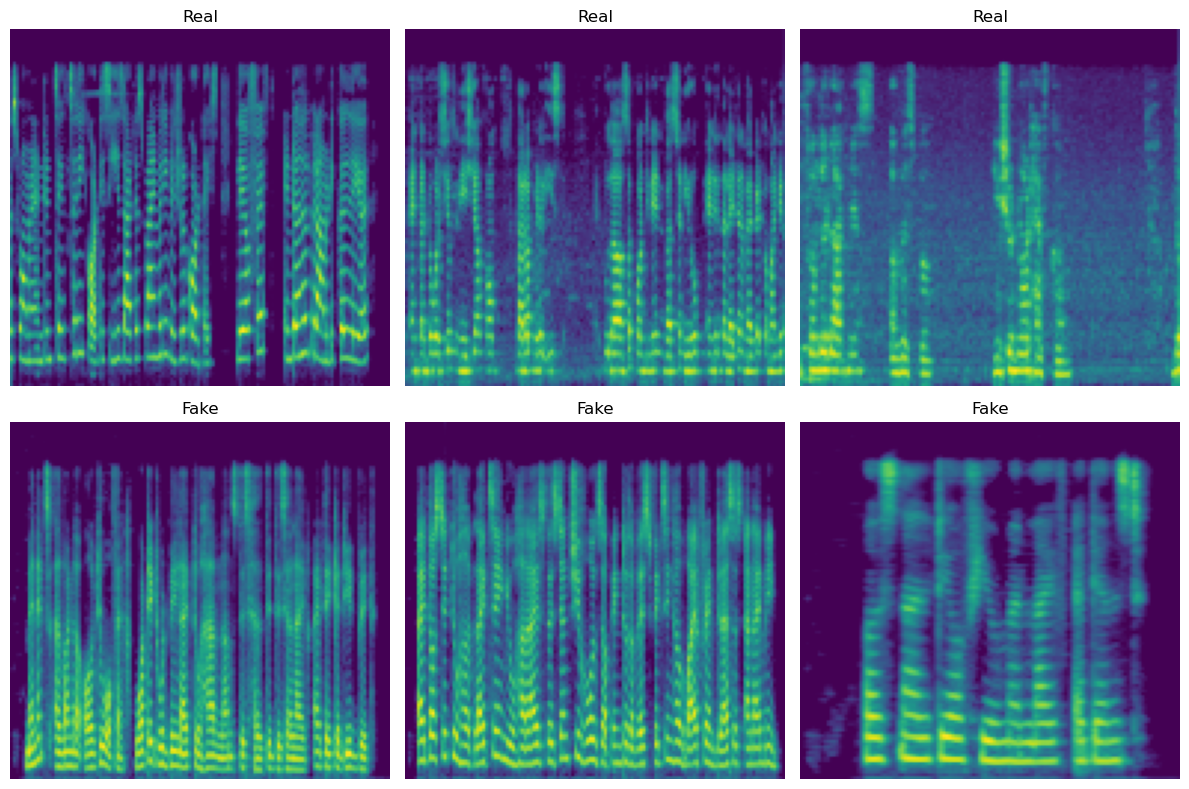

In [17]:
import random
plt.figure(figsize=(12,8))

real_indices = np.where(y_train == 0)[0]
fake_indices = np.where(y_train == 1)[0]

real_samples = random.sample(list(real_indices), 3)
fake_samples = random.sample(list(fake_indices), 3)

# Real
for i, idx in enumerate(real_samples):
    plt.subplot(2,3,i+1)
    plt.imshow(X_train[idx].squeeze(), aspect='auto', origin='lower')
    plt.title("Real")
    plt.axis("off")

# Fake
for i, idx in enumerate(fake_samples):
    plt.subplot(2,3,i+4)
    plt.imshow(X_train[idx].squeeze(), aspect='auto', origin='lower')
    plt.title("Fake")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\PRO\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       3,686,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,705,345 (14.13 MB)

 Trainable params: 3,705,345 (14.13 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 22s 122ms/step - accuracy: 0.9153 - loss: 0.2044 - val_accuracy: 0.9661 - val_loss: 0.1052
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 122ms/step - accuracy: 0.9887 - loss: 0.0342 - val_accuracy: 0.9500 - val_loss: 0.1495
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step - accuracy: 0.9967 - loss: 0.0122 - val_accuracy: 0.9821 - val_loss: 0.0578
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - accuracy: 0.9971 - loss: 0.0118 - val_accuracy: 0.9643 - val_loss: 0.0958
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step - accuracy: 0.9967 - loss: 0.0097 - val_accuracy: 0.9821 - val_loss: 0.0595
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - accuracy: 0.9992 - loss: 0.0032 - val_accuracy: 0.9786 - val_loss: 0.0791
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - accuracy: 0.9992 - loss: 0.0028 - val_accuracy: 0.9464 - val_loss: 0.1658
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 123ms/step - accuracy: 0.9946 - loss: 0

In [20]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9821 - loss: 0.0606     
Test Accuracy: 0.9821428656578064


In [21]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step 
[[274   6]
 [  4 276]]


In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=["Real", "Fake"]))

              precision    recall  f1-score   support

        Real       0.99      0.98      0.98       280
        Fake       0.98      0.99      0.98       280

    accuracy                           0.98       560
   macro avg       0.98      0.98      0.98       560
weighted avg       0.98      0.98      0.98       560



In [23]:
model.save("audio_deepfake_model.h5")

In [24]:
from tensorflow.keras.models import load_model

model = load_model("audio_deepfake_model.h5")

In [25]:
def preprocess_for_prediction(file_path, train_min, train_max):
    
    audio, sr = librosa.load(file_path, sr=22050)
    
    mel = audio_to_melspectrogram(audio, sr)
    mel_resized = resize_spectrogram(mel)
    
    mel_resized = mel_resized.astype("float32")
    
    # Use SAME normalization as training
    mel_resized = (mel_resized - train_min) / (train_max - train_min)
    
    mel_resized = np.expand_dims(mel_resized, axis=0)
    
    return mel_resized

In [26]:
new_file = r"C:\Users\PRO\Desktop\Techolas project\DeepFake\Audio\speaker9_output1_fake.wav" #fake

processed_audio = preprocess_for_prediction(new_file, train_min, train_max)

prediction3 = model.predict(processed_audio)

print("Raw prediction:", prediction3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
Raw prediction: [[1.]]


In [27]:
if prediction3[0][0] > 0.5:
    print("Prediction: FAKE")
else:
    print("Prediction: REAL")

Prediction: FAKE


In [28]:
new_file = r"C:\Users\PRO\Desktop\Techolas project\DeepFake\Audio\speaker11_real.wav" #real

processed_audio = preprocess_for_prediction(new_file, train_min, train_max)

prediction1 = model.predict(processed_audio)

print("Raw prediction:", prediction1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Raw prediction: [[1.4626212e-11]]


In [29]:
if prediction1[0][0] > 0.5:
    print("Prediction: FAKE")
else:
    print("Prediction: REAL")

Prediction: REAL


In [30]:
new_file = r"C:\Users\PRO\Desktop\Techolas project\DeepFake\Audio\speaker2_real.wav" #real

processed_audio = preprocess_for_prediction(new_file, train_min, train_max)

prediction2 = model.predict(processed_audio)

print("Raw prediction:", prediction2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Raw prediction: [[8.744194e-12]]


In [31]:
if prediction2[0][0] > 0.5:
    print("Prediction: FAKE")
else:
    print("Prediction: REAL")

Prediction: REAL


In [32]:
new_file = r"C:\Users\PRO\Desktop\Techolas project\DeepFake\Audio\speaker13_fake.wav" #fake

processed_audio = preprocess_for_prediction(new_file, train_min, train_max)

prediction5 = model.predict(processed_audio)

print("Raw prediction:", prediction5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
Raw prediction: [[0.9999729]]


In [33]:
if prediction5[0][0] > 0.5:
    print("Prediction: FAKE")
else:
    print("Prediction: REAL")

Prediction: FAKE


In [34]:
new_file = r"C:\Users\PRO\Desktop\Techolas project\DeepFake\Audio\speaker33_output13_fake.wav" #fake

processed_audio = preprocess_for_prediction(new_file, train_min, train_max)

prediction6 = model.predict(processed_audio)

print("Raw prediction:", prediction6)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
Raw prediction: [[0.9999998]]


In [35]:
if prediction6[0][0] > 0.5:
    print("Prediction: FAKE")
else:
    print("Prediction: REAL")

Prediction: FAKE


In [36]:
new_file = r"C:\Users\PRO\Desktop\Techolas project\DeepFake\Audio\speaker32_input20_real.wav" #real

processed_audio = preprocess_for_prediction(new_file, train_min, train_max)

prediction7 = model.predict(processed_audio)

print("Raw prediction:", prediction7)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
Raw prediction: [[2.5787706e-20]]


In [37]:
if prediction7[0][0] > 0.5:
    print("Prediction: FAKE")
else:
    print("Prediction: REAL")

Prediction: REAL
